In [1]:

import os
# Make sure you are in scMEDAL_for_scRNAseq dir
# Set up your project path here
#os.chdir("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq")

# from models.models import train_model_on_named_experiment

In [2]:

os.getcwd()

'/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq'

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

### Run $AEC_{batch}$ classifier on all three datasets

```bash
python 1-run_scMEDAL_alldatasets_AECbatch.py
```
### Analyzing Models:

When you run a model, it generates the following output directories:
   - /outputs/figures
   - /outputs/latent_space
   - /outputs/saved_models
 
 Inside each of these directories, there is a subdirectory named after the model and its run identifier.
 
 For example: $HH/latent\_space/aec/run\_crossval\_<run\_name>$

 To analyze your results, copy the corresponding $<run\_name>$ below.
 
### Use precomputed outputs

Alternatively, you can use the precomputed model outputs we shared on Figshare and run the analysis notebook with those files.

To recreate the $AEC_{batch}$ classifier plots from our Figshare `latent_space`, update `OUTPUTS_DIR` in `utils.default` to point to `/outputs_batchclassifier`.


In [3]:

# When you run your model, it outputs the figures, latent_space and saved_models directories, whitin those directories you will find a subdir with the name of the model trained, example: AML/latent_space/scmedalfe/run_crossval_<run_name>
# Please copy the <run_name below> to analyze the results
# Update output paths of the models that you just run

from utils.defaults import HH_OUTPUTS_DIR, HH_EXPERIMENT_NAME
print(f"Loading outputs from {HH_OUTPUTS_DIR}. Please verify that your models output folder is located here before proceeding with the analysis.")
import os
model_folder_dict = {
    "aec":"run_crossval_n_latent_dims-50_layer_units-512-132_n_pred-147_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_get_cf_batch-False_2026-01-16_17-02",



    }

model_paths = {k:os.path.join(HH_OUTPUTS_DIR, "latent_space", HH_EXPERIMENT_NAME,k, v) for k, v in model_folder_dict.items()}




OUTPUTS_DIR: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq/outputs_batchclassifier
Loading outputs from /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq/outputs_batchclassifier/HH. Please verify that your models output folder is located here before proceeding with the analysis.


##### Step 1: Import the analysis class and initialize it

In [4]:

import analysis.analysis as aa

analysis_name = "HH_batchclassifier_500"



hh = aa.HHAnalysis(model_folder_dict, analysis_name)

2026-01-19 16:05:54.731740: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-19 16:05:56.819391: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-19 16:05:56.822298: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-19 16:05:59.043136: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Step 2: Compile clustering scores calculated after training the models

In [5]:

# Clustering scores reported in Figure 2
res= hh.clustering_scores(model_folder_dict)
# You can now inspect or export `clustering_results` as needed
# Note: if you only run 1 fold, you will see NAN in CI entries
res

Directory created or already exists: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq/outputs_batchclassifier/HH/compare_models/log_transformed_3000hvggenes/HH_batchclassifier_500

Computed aggregated scores DataFrame
Computed Confidence interval results for sample size: 10000, saved to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq/outputs_batchclassifier/HH/compare_models/log_transformed_3000hvggenes/HH_batchclassifier_500
 


batch                                                         \
              1/db                        ch                   silhouette   
              mean CI_lower CI_upper    mean CI_lower CI_upper       mean   
dataset_type                                                                
aec           0.14     0.13     0.14  324.94   274.41   375.48      -0.13   

                               celltype                                     \
                                   1/db                        ch            
             CI_lower CI_upper     mean CI_lower CI_upper    mean CI_lower   
dataset_type                                                                 
aec             -0.16     -0.1     0.21     0.17     0.24  356.23   277.67   

                                                    
                      silhouette                    
             CI_upper       mean CI_lower CI_upper  
dataset_type                                        
aec             434.8      -0.08    -0.12    -0.03

##### Step 3: Generate and save the UMAP plots

In [6]:

# This typically loads latent representations stored after training and creates UMAPs for each model
processors = hh.umap(model_folder_dict, types=["train"], splits=[1])
processors

Reading inputs and latent paths ..
umap saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq/outputs_batchclassifier/HH/compare_models/log_transformed_3000hvggenes/HH_batchclassifier_500/umap_19batches_seed_5
Computing UMAP projections...


Processing input prefix: 0 train_1
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/batchclassifiertest/scMEDAL_for_scRNAseq/data/HH_data/log_transformed_3000hvggenes/splits/split_1/train


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Scenario 2: Processing input subset batches (train_1)

Processing input sample
Computing UMAP on 41544 cells * 3000 features, using 'X_pca'
UMAP shape: (41544, 2)

Scenario 4: Processing latent subset batches (train_1)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Processing: aec_latent_train_1
Computing UMAP on 41544 cells * 50 features, using 'X'
UMAP shape: (41544, 2)



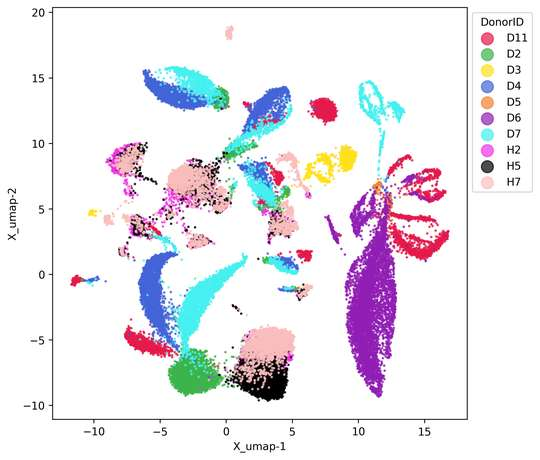
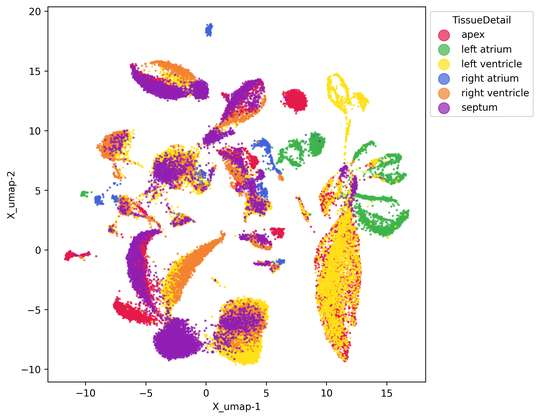
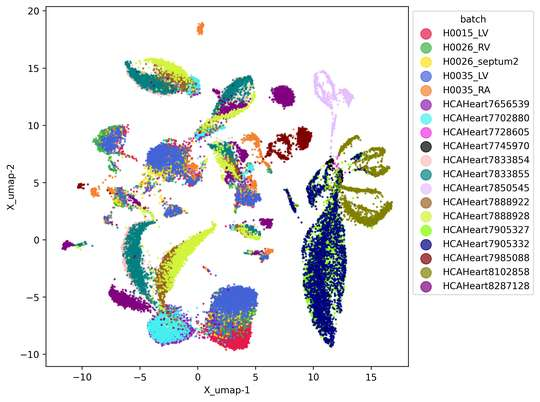
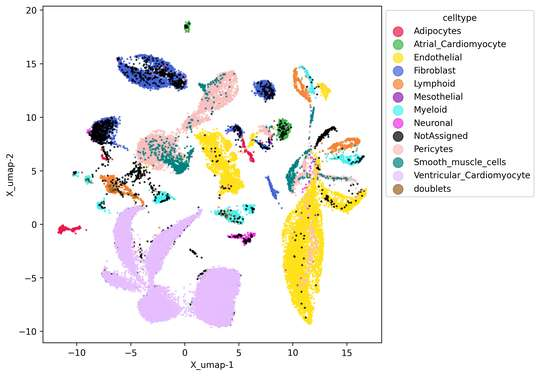
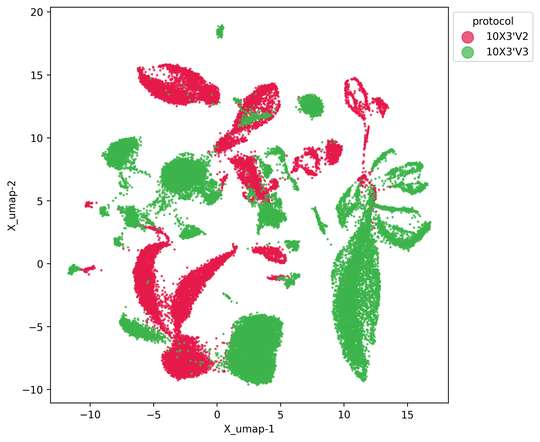

In [7]:
# UMAP viewer for AEC batch classifier
import os, glob, re, io, base64, html
from IPython.display import HTML, display
from PIL import Image as PILImage


# ------------------------------
# Tunables
# ------------------------------
models2plot   = ["aec"]
thumb_css_w   = 200   # visual width (px) of each thumbnail
max_side_px   = 540   # actual embedded image max side (px); lower -> smaller ipynb
jpeg_quality  = 60    # 55?70 good for thumbnails; lower -> smaller ipynb
valid_ext     = (".png",".jpg",".jpeg",".tif",".tiff")


outputs_path = os.path.join(hh.paths.outputs_path, analysis_name)
if not outputs_path or not os.path.isdir(outputs_path):
    display(HTML("<b style='color:#b00'>Define <code>outputs_path</code> to your outputs directory before running this cell.</b>"))
else:
    # 1) Collect candidates
    all_umap_figs = sorted(
        p for p in glob.glob(os.path.join(outputs_path, "**", "*umap*", "*plots_axis*", "*umap*"), recursive=True)
        if os.path.splitext(p)[1].lower() in valid_ext and os.path.isfile(p)
    )

    def to_data_uri_compressed(fp: str) -> str:
        """Open, downscale to max_side_px, JPEG-compress in-memory, return data URI."""
        with PILImage.open(fp) as im:
            # flatten alpha onto white; ensure RGB
            if im.mode in ("RGBA","LA"):
                bg = PILImage.new("RGB", im.size, (255,255,255))
                bg.paste(im, mask=im.split()[-1])
                im = bg
            else:
                im = im.convert("RGB")
            w, h = im.size
            m = max(w, h)
            if m > max_side_px:
                scale = m / float(max_side_px)
                im = im.resize((int(round(w/scale)), int(round(h/scale))), PILImage.LANCZOS)
            buf = io.BytesIO()
            im.save(buf, format="JPEG", quality=jpeg_quality, optimize=True, progressive=True, subsampling=2)
            b64 = base64.b64encode(buf.getvalue()).decode("ascii")
            return f"data:image/jpeg;base64,{b64}"

    # 2) Build rows (one per model), using regex boundaries to avoid partial-name collisions
    rows_html = []
    for model in models2plot:
        pat = re.compile(rf"(?i)(?<![a-z0-9]){re.escape(model)}(?![a-z0-9])")  # non-alnum boundaries
        model_figs = [p for p in all_umap_figs if pat.search(os.path.basename(p)) or pat.search(p)]

        if not model_figs:
            row_imgs = "<div style='color:#666;font-style:italic;'>No figures found</div>"
        else:
            thumbs = []
            for p in model_figs:
                try:
                    data_uri = to_data_uri_compressed(p)
                    rel = html.escape(os.path.relpath(p, outputs_path))
                    thumbs.append(
                        f"<a href='{rel}' target='_blank' rel='noopener' title='{rel}'>"
                        f"<img src='{data_uri}' style='width:{thumb_css_w}px; height:auto; display:block;'>"
                        f"</a>"
                    )
                except Exception as ex:
                    thumbs.append(f"<div style='color:#b00'>[skip {html.escape(os.path.basename(p))}: {html.escape(str(ex))}]</div>")
            row_imgs = "".join(thumbs)

        row_html = f"""
          <div class="row" style="display:flex; gap:12px; align-items:flex-start; margin:6px 0;">
            <div class="label"
                 style="position:sticky; left:0; flex:0 0 170px; max-width:170px;
                        background:#fff; border-right:1px solid #eee; padding:8px 12px;
                        font-weight:600; text-transform:uppercase; letter-spacing:0.5px;">
              {html.escape(model)} <span style="color:#888; font-weight:400;">({len(model_figs)})</span>
            </div>
            <div class="strip"
                 style="display:flex; flex-wrap:nowrap; gap:8px; overflow-x:auto; padding:8px 4px; border-bottom:1px dashed #eee;">
              {row_imgs}
            </div>
          </div>
        """
        rows_html.append(row_html)

    full_html = f"""
    <div style="display:block; width:100%; line-height:0;">
      <div style="margin:8px 0 10px; font-size:14px; color:#444; line-height:1.4;">
        <b>UMAP Image Viewer</b>  one row per model (compressed in-memory; no files written).
      </div>
      {''.join(rows_html)}
    </div>
    """
    display(HTML(full_html))